In [12]:
import xarray as xr
import numpy as np

In [13]:
radar_35 = xr.open_mfdataset(r'C:\Users\chari\Downloads\*P00_ZEN.LV1.nc')

C:\Users\chari\AppData\Local\Temp\ipykernel_4136\2121223749.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  radar_35 = xr.open_mfdataset(r'C:\Users\chari\Downloads\*P00_ZEN.LV1.nc')


In [14]:
radar_35

<xarray.Dataset> Size: 170MB
Dimensions:      (Time: 8213, TAlt: 93, HAlt: 93, Chirp: 3, C1Range: 37,
                  C2Range: 94, C3Range: 179)
Coordinates:
  * Time         (Time) uint32 33kB 742813201 742813204 ... 742838395 742838398
  * C1Range      (C1Range) float32 148B 119.2 149.1 ... 1.163e+03 1.192e+03
  * C2Range      (C2Range) float32 376B 1.222e+03 1.252e+03 ... 3.995e+03
  * C3Range      (C3Range) float32 716B 4.025e+03 4.069e+03 ... 1.198e+04
Dimensions without coordinates: TAlt, HAlt, Chirp
Data variables: (12/98)
    ProgNo       (Time) int32 33kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    ModelNo      (Time) int32 33kB 3 3 3 3 3 3 3 3 3 3 3 ... 3 3 3 3 3 3 3 3 3 3
    Freq         (Time) float32 33kB 35.0 35.0 35.0 35.0 ... 35.0 35.0 35.0 35.0
    AntSep       (Time) float32 33kB 0.768 0.768 0.768 ... 0.768 0.768 0.768
    AntDia       (Time) float32 33kB 0.7 0.7 0.7 0.7 0.7 ... 0.7 0.7 0.7 0.7 0.7
    AntG         (Time) float32 33kB 5.754e+04 5.754e+04 ... 5.754e+04 5.754e+04
    ...           ...
    C3RHV        (Time, C3Range) float32 6MB dask.array<chunksize=(1170, 179), meta=np.ndarray>
    C3PhiDP      (Time, C3Range) float32 6MB dask.array<chunksize=(1170, 179), meta=np.ndarray>
    C3SLDR       (Time, C3Range) float32 6MB dask.array<chunksize=(1170, 179), meta=np.ndarray>
    C3SRCX       (Time, C3Range) float32 6MB dask.array<chunksize=(1170, 179), meta=np.ndarray>
    C3KDP        (Time, C3Range) float32 6MB dask.array<chunksize=(1170, 179), meta=np.ndarray>
    C3DiffAtt    (Time, C3Range) float32 6MB dask.array<chunksize=(1170, 179), meta=np.ndarray>
Attributes:
    Program name:  Doppler 3 sec
    Customer:      DELFT3-K

In [15]:
db1 = 10 * np.log10(radar_35.C1ZE.values)  # shape: (range1, time)
db2 = 10 * np.log10(radar_35.C2ZE.values)  # shape: (range2, time)
db3 = 10 * np.log10(radar_35.C3ZE.values)  # shape: (range2, time)

rho_1 = radar_35.C1RHV.values
rho_2 = radar_35.C2RHV.values
rho_3 = radar_35.C3RHV.values
time = radar_35.Time.values
z1 = radar_35.C1Range.values  # shape: (range1,)
z2 = radar_35.C2Range.values  # shape: (range2,)
z3 = radar_35.C3Range.values  # shape: (range2,)
db1 = db1.T   # → (37, 1245)
db2 = db2.T   # → (94, 1245)
db3 = db3.T
rho_1 = rho_1.T
rho_2 = rho_2.T
rho_3 = rho_3.T
db_combined = np.vstack([db1, db2,db3])   # (131, 1245)
rho_combined = np.vstack([rho_1, rho_2,rho_3])
z_combined  = np.concatenate([z1, z2,z3])


In [16]:
print(db1.shape, db2.shape)

(37, 8213) (94, 8213)


In [17]:
import pickle
with open(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\ES25\era5_datasets_sens_T_plus.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Now you can access your original variables
rain_rate = loaded_data['rain_rate']
time_min = loaded_data['time']
X_min = loaded_data['state']
R_min = loaded_data['R']
Z_t_min = loaded_data['Z_t']
Z_t_min = loaded_data['Z_t_new']
metadata_min = loaded_data['metadata']

In [18]:
import pandas as pd

# Convert seconds since 2001-01-01 into datetime64
time = pd.to_datetime(radar_35.Time.values, unit='s', origin=pd.Timestamp("2001-01-01"))

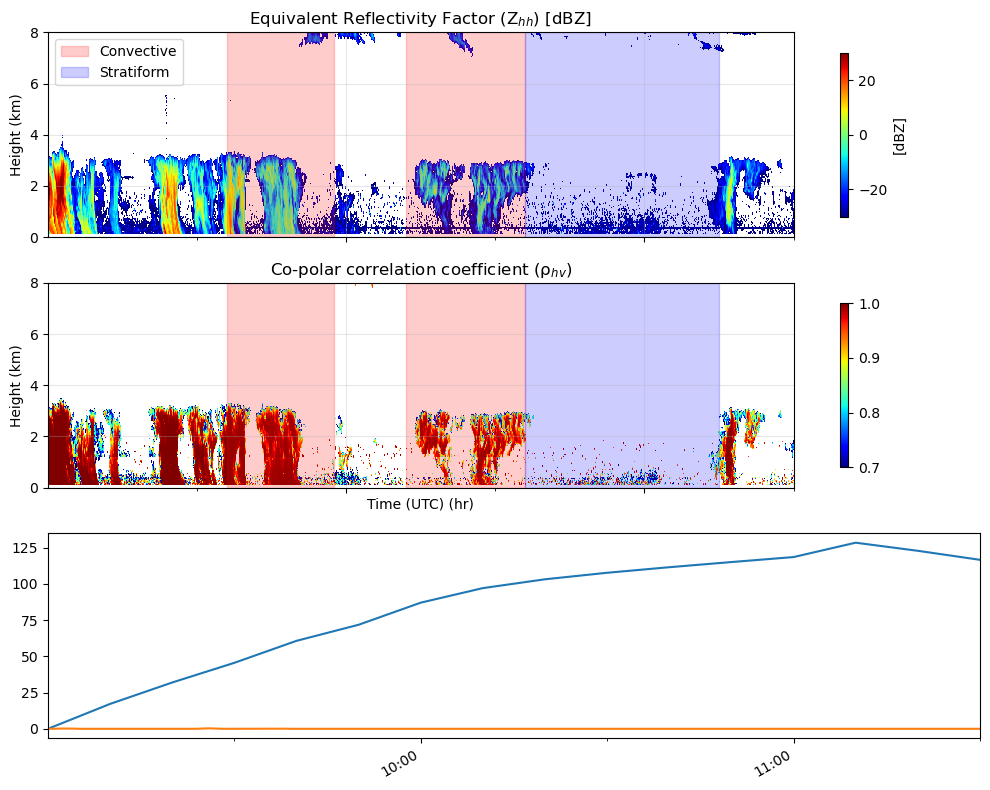

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Make sure db has shape (time, range). If not, transpose
db_plot = db_combined  # (range × time → time × range)
rho_plot = rho_combined

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Reflectivity plot ---
pc1 = ax1.pcolormesh(time, z_combined/1000, db_plot, shading='auto',  # Convert height to km
                     cmap='jet', vmin=-30, vmax=30)
cbar1 = plt.colorbar(pc1, ax=ax1, label="[dBZ]", shrink=0.8)
ax1.set_ylabel("Height (km)")
ax1.set_title("Equivalent Reflectivity Factor (Z$_{hh}$) [dBZ]", fontsize=12)
ax1.set_ylim(0, 8)  # Limit height to 8 km like first image
ax1.set_xlim(time[0],time[0]+ pd.Timedelta(hours=2.5))
# Add classification regions using hours relative to start time
# This assumes your time array spans several hours
start_time = time[0] 
ax1.axvspan(start_time + pd.Timedelta(hours=0.6), start_time + pd.Timedelta(hours=0.96), 
            alpha=0.2, color='red', label='Convective')
ax1.axvspan(start_time +  pd.Timedelta(hours=1.2), start_time + pd.Timedelta(hours=1.6), 
            alpha=0.2, color='red')
ax1.axvspan(start_time + pd.Timedelta(hours=1.6), start_time + pd.Timedelta(hours=2.25), 
            alpha=0.2, color='blue', label='Stratiform')

# --- Rho (correlation coefficient) plot ---
pc2 = ax2.pcolormesh(time, z_combined/1000, rho_plot, shading='auto',  # Convert height to km
                     cmap='jet', vmin=0.7, vmax=1.0)  # Changed colormap and range to match first image
cbar2 = plt.colorbar(pc2, ax=ax2, label="", shrink=0.8)  # No label to match first image
ax2.set_ylabel("Height (km)")
ax2.set_xlabel("Time (UTC) (hr)")
ax2.set_title("Co-polar correlation coefficient (ρ$_{hv}$)", fontsize=12)
ax2.set_ylim(0, 8)  # Limit height to 8 km

# Add the same classification regions to the bottom panel
start_time = time[0]
ax2.axvspan(start_time + pd.Timedelta(hours=0.6), start_time + pd.Timedelta(hours=0.96), 
            alpha=0.2, color='red', label='Stratiform')
ax2.axvspan(start_time +  pd.Timedelta(hours=1.2), start_time + pd.Timedelta(hours=1.6), 
            alpha=0.2, color='red', label='Stratiform')
ax2.axvspan(start_time + pd.Timedelta(hours=1.6), start_time + pd.Timedelta(hours=2.25), 
            alpha=0.2, color='blue', label='Convective')
# Format time axis to show only hours:minutes like first image
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))  # Major ticks every hour
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=30))  # Minor ticks every 30 min

ax3.plot(time_min,R_min*3600)
ax3.plot(rain_rate.time,rain_rate)
# Set time range to match first image (adjust as needed for your data)
# Uncomment and modify these lines based on your actual time range
# ax2.set_xlim(time[0], time[0] + pd.Timedelta(hours=5))  # Show ~5 hour window

# Adjust layout to be more compact like first image
plt.subplots_adjust(hspace=0.3)
fig.autofmt_xdate()

# Make the plot look cleaner
for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.8)
plt.tight_layout()
plt.show()




In [22]:
time

DatetimeIndex(['2024-07-16 09:00:01', '2024-07-16 09:00:04',
               '2024-07-16 09:00:07', '2024-07-16 09:00:11',
               '2024-07-16 09:00:14', '2024-07-16 09:00:17',
               '2024-07-16 09:00:20', '2024-07-16 09:00:23',
               '2024-07-16 09:00:26', '2024-07-16 09:00:29',
               ...
               '2024-07-16 15:59:31', '2024-07-16 15:59:34',
               '2024-07-16 15:59:37', '2024-07-16 15:59:40',
               '2024-07-16 15:59:43', '2024-07-16 15:59:46',
               '2024-07-16 15:59:49', '2024-07-16 15:59:52',
               '2024-07-16 15:59:55', '2024-07-16 15:59:58'],
              dtype='datetime64[ns]', length=8213, freq=None)

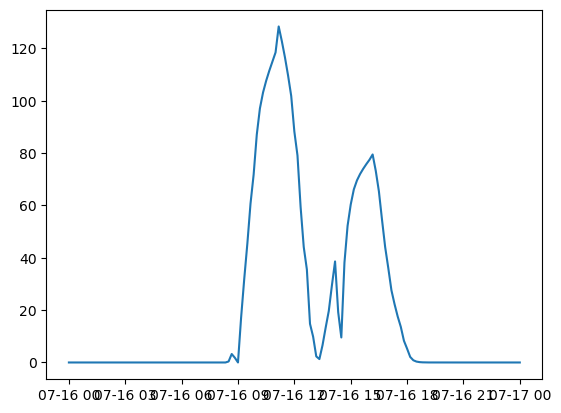

In [20]:
plt.plot(time_min,R_min*3600)

In [21]:
import matplotlib.pyplot as plt
precip = ds['tp']
precip = precip.sel(latitude='52',longitude='5')
plt.plot(precip.time,precip.values)

NameError: name 'ds' is not defined

In [ ]:
hourly_tp = ds['tp'].diff("step")

# assign valid_time to match mid-interval
hourly_tp = hourly_tp.assign_coords(valid_time=ds['valid_time'].isel(step=slice(1, None)))

In [ ]:
hourly_tp.sel(latitude='52',longitude='5')

<xarray.DataArray 'tp' (time: 3, step: 11)> Size: 132B
array([[            nan,             nan,             nan,
                    nan,             nan, -1.37710571e-03,
        -4.07218933e-04,  4.29153442e-06,  3.81469727e-06,
         1.04904175e-05, -7.15255737e-06],
       [ 1.01089478e-04,  2.09808350e-05, -8.29696655e-05,
         7.24792480e-05,  2.23922729e-03, -9.82284546e-04,
        -1.09481812e-03, -2.26020813e-04, -1.90734863e-05,
         6.88552856e-04, -5.87463379e-04],
       [-1.90734863e-06,  2.00271606e-05, -2.47955322e-05,
        -6.67572021e-06,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan]], dtype=float32)
Coordinates:
    number      int32 4B ...
  * time        (time) datetime64[ns] 24B 2024-07-15T18:00:00 ... 2024-07-16T...
  * step        (step) timedelta64[ns] 88B 02:00:00 03:00:00 ... 12:00:00
    surface     float64 8B ...
    latitude    float64 8B 52.0
    longitude   float64 8B 5.0
    valid_time  (time, step) datetime64[ns] 264B ...

In [ ]:
import xarray as xr
import pandas as pd

def extract_hourly_precip(ds, lat, lon):
    """
    Extract continuous hourly precipitation (mm/h) from ERA5/GRIB data.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with 'tp' (total precipitation, meters).
    lat : float
        Latitude of the point of interest.
    lon : float
        Longitude of the point of interest.

    Returns
    -------
    pandas.Series
        Hourly precipitation time series in mm/h, indexed by valid_time.
    """

    # Select nearest gridpoint
    tp_point = ds['tp'].sel(latitude=lat, longitude=lon, method="nearest")

    # Convert from cumulative (per forecast step) to hourly increments
    # Align to valid_time
    tp_incr = tp_point.diff("step")
    tp_incr = tp_incr.assign_coords(valid_time=tp_point.valid_time.isel(step=slice(1, None)))

    # Convert from meters → mm
    tp_mm = tp_incr * 1000

    # Drop NaNs (first diff is NaN by definition)
    tp_mm = tp_mm.fillna(0)

    # Convert to pandas time series
    ts = tp_mm.groupby("valid_time").sum().to_pandas()

    # Clip tiny negatives due to round-off
    ts = ts.clip(lower=0)

    return ts

precip_ts = extract_hourly_precip(ds, lat=52.0, lon=5)

print(precip_ts)

valid_time
2024-07-15 20:00:00    0.000000
2024-07-15 21:00:00    0.000000
2024-07-15 22:00:00    0.000000
2024-07-15 23:00:00    0.000000
2024-07-16 00:00:00    0.000000
2024-07-16 01:00:00    0.000000
2024-07-16 02:00:00    0.000000
2024-07-16 03:00:00    0.004292
2024-07-16 04:00:00    0.003815
2024-07-16 05:00:00    0.010490
2024-07-16 06:00:00    0.000000
2024-07-16 08:00:00    0.101089
2024-07-16 09:00:00    0.020981
2024-07-16 10:00:00    0.000000
2024-07-16 11:00:00    0.072479
2024-07-16 12:00:00    2.239227
2024-07-16 13:00:00    0.000000
2024-07-16 14:00:00    0.000000
2024-07-16 15:00:00    0.000000
2024-07-16 16:00:00    0.000000
2024-07-16 17:00:00    0.688553
2024-07-16 18:00:00    0.000000
2024-07-16 20:00:00    0.000000
2024-07-16 21:00:00    0.020027
2024-07-16 22:00:00    0.000000
2024-07-16 23:00:00    0.000000
2024-07-17 00:00:00    0.000000
2024-07-17 01:00:00    0.000000
2024-07-17 02:00:00    0.000000
2024-07-17 03:00:00    0.000000
2024-07-17 04:00:00    0.0000

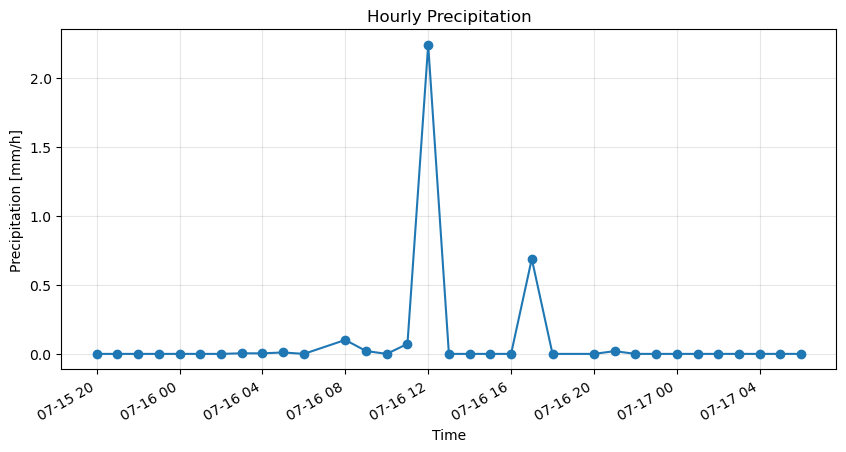

In [ ]:

plt.figure(figsize=(10,5))
precip_ts.plot(marker="o", linestyle="-")
plt.title("Hourly Precipitation")
plt.ylabel("Precipitation [mm/h]")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
precip_ts.valid_time

AttributeError: 'Series' object has no attribute 'valid_time'

In [ ]:
data_rain = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\ERA5\surface\surface_era_1607.nc')

In [ ]:
import xarray as xr

# open GRIB file with cfgrib engine
ds = xr.open_dataset(r"C:\Users\chari\Downloads\666f0406fb2ce6c417574bab2309946.grib", engine="cfgrib")

print(ds)
print(ds.variables)

<xarray.Dataset> Size: 4kB
Dimensions:     (time: 3, step: 12, latitude: 5, longitude: 5)
Coordinates:
    number      int32 4B ...
  * time        (time) datetime64[ns] 24B 2024-07-15T18:00:00 ... 2024-07-16T...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 40B 52.0 51.75 51.5 51.25 51.0
  * longitude   (longitude) float64 40B 4.0 4.25 4.5 4.75 5.0
    valid_time  (time, step) datetime64[ns] 288B ...
Data variables:
    tp          (time, step, latitude, longitude) float32 4kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-12T22:19 GRIB to CDM+CF via cfgrib-0.9.1...
Frozen({'number': <xarray.Variable

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\cfgrib\xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
